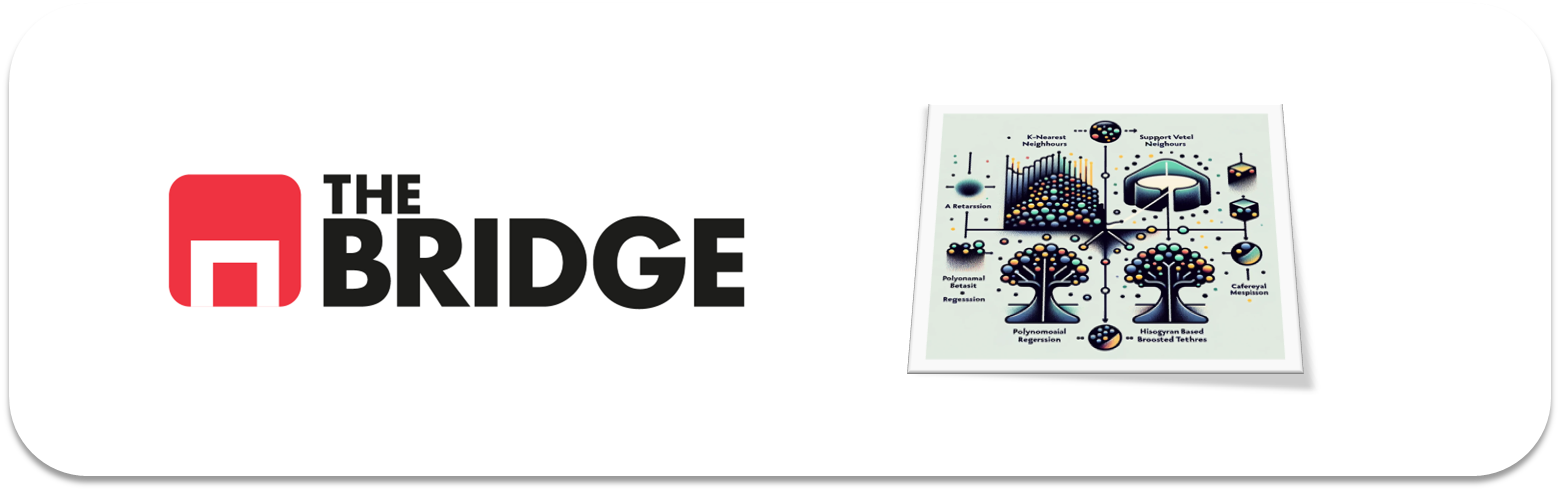

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [155]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Clasificacion
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# Regresion
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

# Utilidades
from sklearn.metrics import (
    balanced_accuracy_score, classification_report, ConfusionMatrixDisplay,
    mean_absolute_error, mean_absolute_percentage_error, r2_score
)
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

import toolbox_ml.eda.core as eda

### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

In [156]:
# Carga del dataset (separador pipe)
df = pd.read_csv('./data/wines_dataset.csv', sep='|')

print(f'Shape: {df.shape}')
df.head()

Shape: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red


In [157]:
df.info()
print()
eda.describe_df(df)

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 688.6 KB



,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
fixed acidity,float64,0.0,106,1.631522
volatile acidity,float64,0.0,187,2.878252
citric acid,float64,0.0,89,1.369863
residual sugar,float64,0.0,316,4.863783
chlorides,float64,0.0,214,3.293828
free sulfur dioxide,float64,0.0,135,2.077882
total sulfur dioxide,float64,0.0,276,4.248115
density,float64,0.0,998,15.360936
pH,float64,0.0,108,1.662306
sulphates,float64,0.0,111,1.708481


In [158]:
# Definicion de targets
target_clf = 'quality'   # clasificacion: predecir calidad del vino (3-9)
target_reg = 'alcohol'   # regresion: predecir grado alcoholico

print(f"Target clasificacion: '{target_clf}'")
print(df[target_clf].value_counts().sort_index())
print()
print(f"Target regresion: '{target_reg}'")
print(df[target_reg].describe().round(3))

Target clasificacion: 'quality'
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

Target regresion: 'alcohol'
count    6497.000
mean       10.492
std         1.193
min         8.000
25%         9.500
50%        10.300
75%        11.300
max        14.900
Name: alcohol, dtype: float64


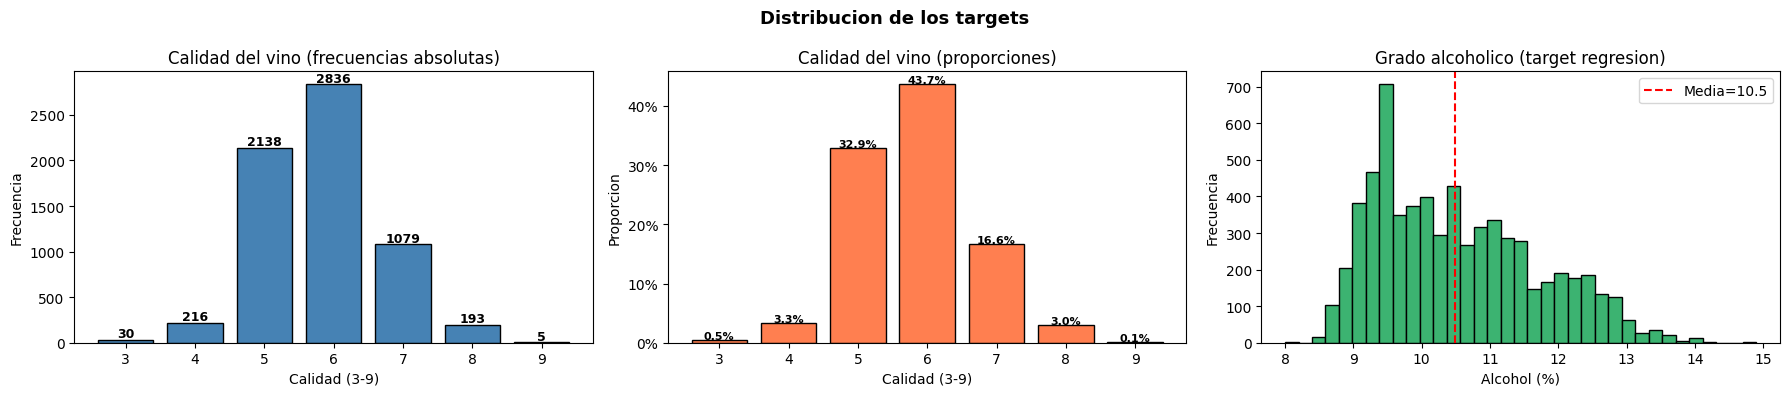

In [159]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Distribucion calidad (target clasificacion)
counts = df[target_clf].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Calidad del vino (frecuencias absolutas)')
axes[0].set_xlabel('Calidad (3-9)'); axes[0].set_ylabel('Frecuencia')
for x, v in zip(counts.index, counts.values):
    axes[0].text(x, v + 30, str(v), ha='center', fontsize=9, fontweight='bold')

# Proporciones calidad
props = df[target_clf].value_counts(normalize=True).sort_index()
axes[1].bar(props.index, props.values, color='coral', edgecolor='black')
axes[1].set_title('Calidad del vino (proporciones)')
axes[1].set_xlabel('Calidad (3-9)'); axes[1].set_ylabel('Proporcion')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
for x, v in zip(props.index, props.values):
    axes[1].text(x, v + 0.002, f'{v:.1%}', ha='center', fontsize=8, fontweight='bold')

# Distribucion alcohol (target regresion)
axes[2].hist(df[target_reg], bins=35, color='mediumseagreen', edgecolor='black')
axes[2].set_title('Grado alcoholico (target regresion)')
axes[2].set_xlabel('Alcohol (%)'); axes[2].set_ylabel('Frecuencia')
axes[2].axvline(df[target_reg].mean(), color='red', linestyle='--',
                label=f'Media={df[target_reg].mean():.1f}')
axes[2].legend()

plt.suptitle('Distribucion de los targets', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Assessment de los problemas

**Problema de clasificacion (target: `quality`)**

| Clase | n | % |
|-------|---|---|
| 3 | 30 | 0.5% |
| 4 | 216 | 3.3% |
| 5 | 2138 | 32.9% |
| 6 | 2836 | 43.6% |
| 7 | 1079 | 16.6% |
| 8 | 193 | 3.0% |
| 9 | 5 | 0.1% |

Es un problema de **clasificacion multiclase (7 clases)** muy desbalanceado. Las clases 3 y 9 tienen tan pocas muestras que un `StratifiedKFold` con k=5 tendria menos de 2 muestras por fold. Para estabilizar la validacion cruzada **agrupamos clases extremas (3->4 y 9->8)**, quedando 5 clases. La metrica objetivo del negocio es **`balanced_accuracy`** (media del recall por clase), que penaliza el olvido de clases minoritarias.

**Problema de regresion (target: `alcohol`)**

El grado alcoholico oscila entre 8% y 14.9%, con media ~10.5%. La distribucion es ligeramente asimetrica a la derecha. El negocio quiere minimizar el **MAPE** (Mean Absolute Percentage Error): un MAPE del 5% significaria ~0.5% de error medio sobre un vino de 10%.

### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

In [160]:
# PREPARACION PARA CLASIFICACION
df_clf = df.copy()

# Agrupamos clases extremas (3->4, 9->8) para estabilizar la CV
df_clf[target_clf] = df_clf[target_clf].replace({3: 4, 9: 8})
print('Distribucion tras agrupar 3->4 y 9->8:')
print(df_clf[target_clf].value_counts().sort_index())

# Codificamos la variable categorica 'class' (white/red)
le = LabelEncoder()
df_clf['class_enc'] = le.fit_transform(df_clf['class'])
print(f'\nclass mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Para XGBoost el target debe ser 0-indexado (4->0, 5->1, 6->2, 7->3, 8->4)
quality_min = df_clf[target_clf].min()
print(f'\nDesplazamiento para XGB: calidad - {quality_min}')

Distribucion tras agrupar 3->4 y 9->8:
quality
4     246
5    2138
6    2836
7    1079
8     198
Name: count, dtype: int64

class mapping: {'red': np.int64(0), 'white': np.int64(1)}

Desplazamiento para XGB: calidad - 4


Vemos las variables que pueden ser interesantes para nuestro estudio

In [161]:
features_cat = eda.get_features_cat_regression(df_clf, target_clf, pvalue=0.05)
features_num = eda.get_features_num_regression(df_clf, target_clf, umbral_corr=0.1, pvalue=0.05)
features_clf = features_num + ["class_enc"]  # Incluimos la variable categorica codificada
features_clf = [c for c in features_clf if c not in [target_clf]]

In [162]:
# Split estratificado (mantiene proporcion de clases en train/test)
train_clf, test_clf = train_test_split(
    df_clf.drop(columns=['class']),
    test_size=0.2, random_state=42, stratify=df_clf[target_clf]
)

X_train_clf = train_clf[features_clf].copy()
y_train_clf = train_clf[target_clf]
X_test_clf  = test_clf[features_clf].copy()
y_test_clf  = test_clf[target_clf]

print(f'Train: {X_train_clf.shape}  |  Test: {X_test_clf.shape}')
print(f'Features: {features_clf}')
print('\nDistribucion y_train_clf:')
print(y_train_clf.value_counts(normalize=True).sort_index().map(lambda x: f'{x:.1%}'))

Train: (5197, 5)  |  Test: (1300, 5)
Features: ['volatile acidity', 'chlorides', 'density', 'alcohol', 'class_enc']

Distribucion y_train_clf:
quality
4     3.8%
5    32.9%
6    43.7%
7    16.6%
8     3.0%
Name: proportion, dtype: str


In [163]:
X_train_clf.info()

<class 'pandas.DataFrame'>
Index: 5197 entries, 6375 to 6131
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   volatile acidity  5197 non-null   float64
 1   chlorides         5197 non-null   float64
 2   density           5197 non-null   float64
 3   alcohol           5197 non-null   float64
 4   class_enc         5197 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 243.6 KB


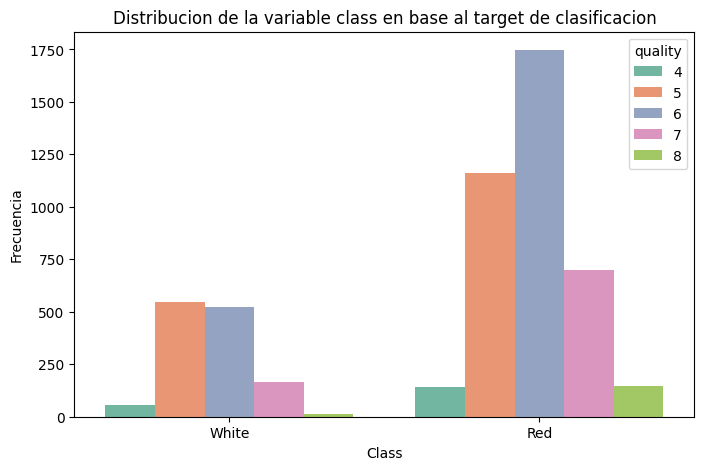

In [164]:
# Representamos la distribucion de la variable class en base al target de clasificacion. class_enc es numerica 0-1, lo cambiamos por white y red para que sea mas entendible
plt.figure(figsize=(8, 5))
sns.countplot(data=pd.concat([X_train_clf, y_train_clf], axis=1), x='class_enc', hue=target_clf, palette='Set2')
plt.title('Distribucion de la variable class en base al target de clasificacion')
plt.xlabel('Class')
plt.ylabel('Frecuencia')
plt.xticks(ticks=[0, 1], labels=['White', 'Red'])
plt.show()

['volatile acidity', 'chlorides', 'density', 'alcohol']

Error in callback <function _draw_all_if_interactive at 0x0000026BF3EAB530> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

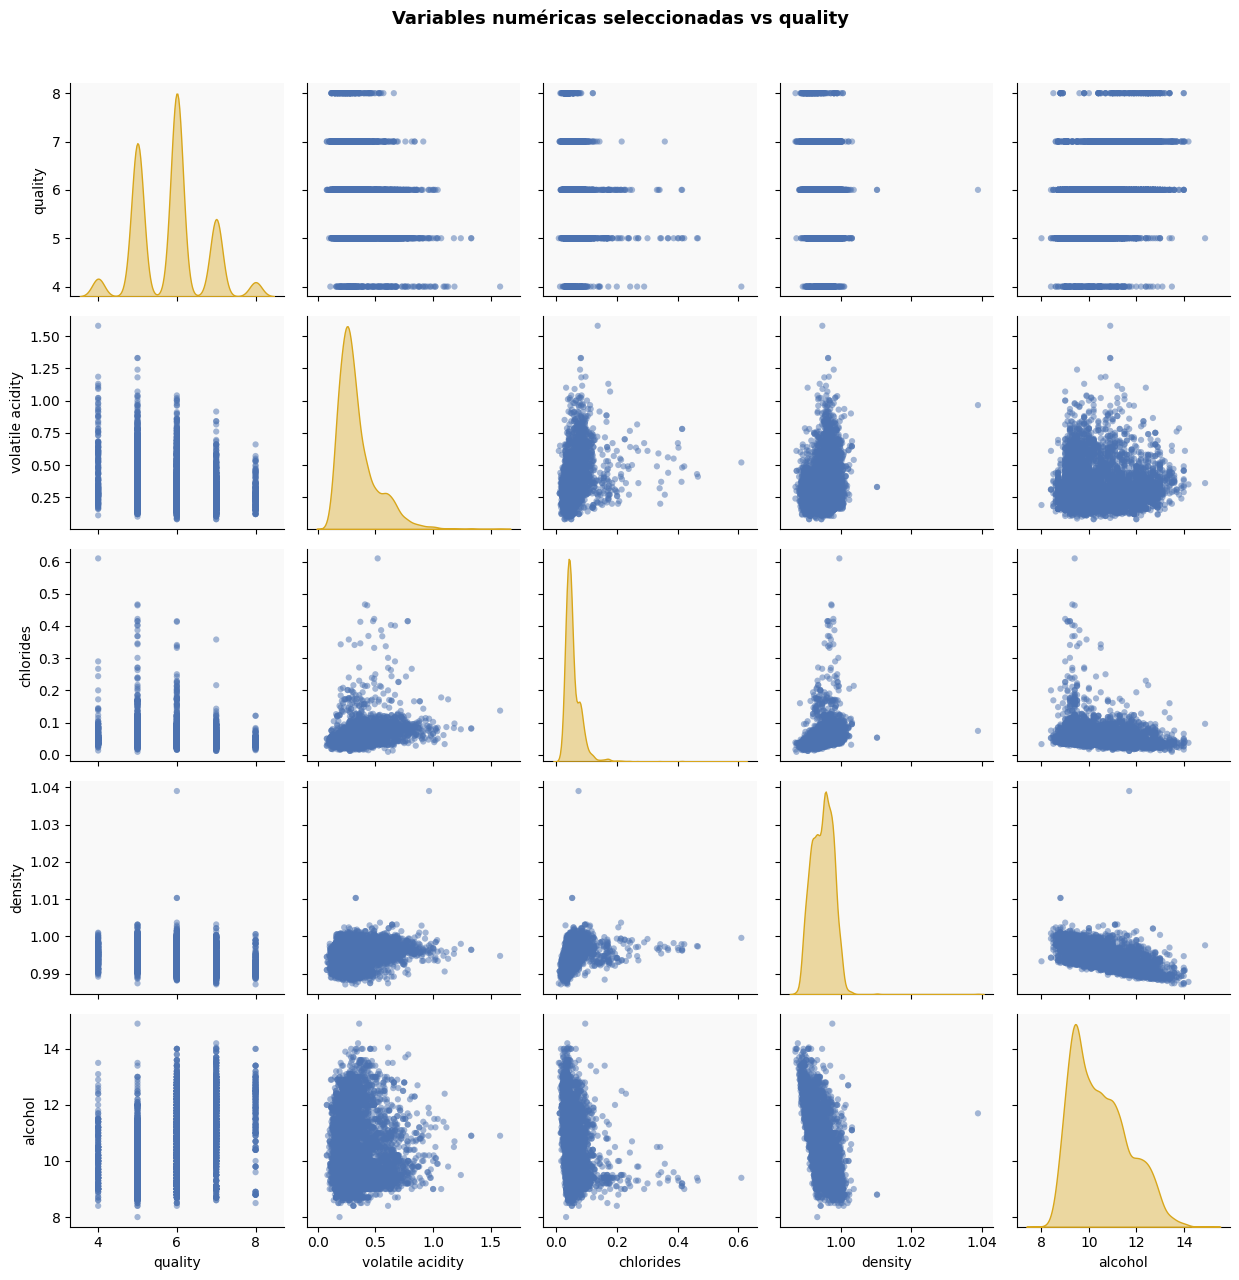

In [165]:
eda.plot_features_num_regression(pd.concat([X_train_clf, y_train_clf], axis=1), target_clf)

array([<Axes: title={'center': 'volatile acidity'}>,
       <Axes: title={'center': 'density'}>,
       <Axes: title={'center': 'chlorides'}>,
       <Axes: title={'center': 'alcohol'}>], dtype=object)

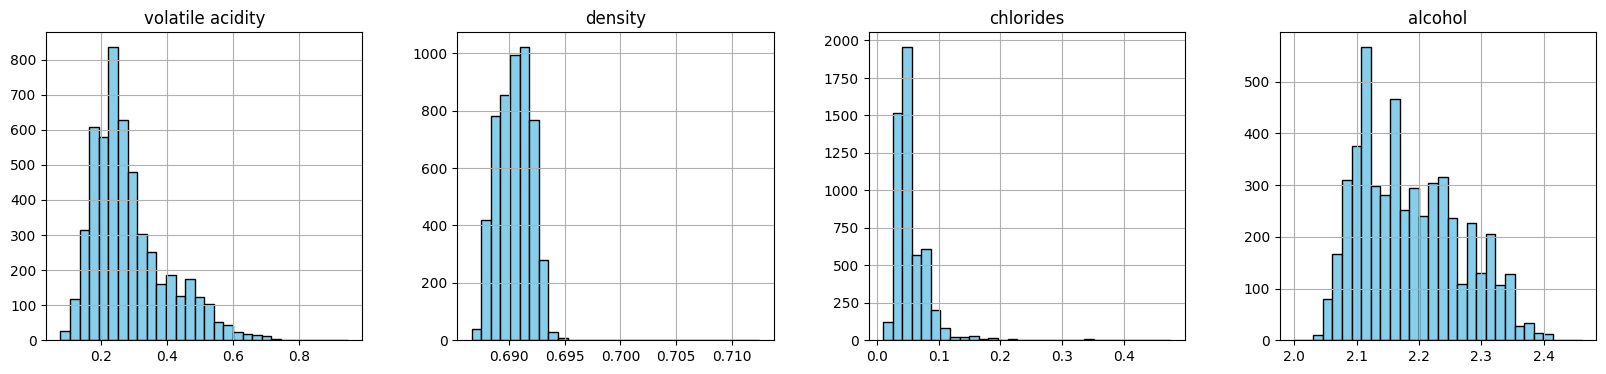

In [ ]:
# Transformamos las variables volatile acidity, density y chlorides para mejorar la distribucion (log1p)
log_df = X_train_clf[['volatile acidity', 'density', 'chlorides']].apply(np.log1p)
log_df = pd.concat([log_df,np.cbrt(X_train_clf['alcohol'])], axis=1)
# Representamos la distribucion de las variables transformadas
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
log_df.hist(bins=30, ax=axes, color='skyblue', edgecolor='black')


Se observa que tenemos unas variables normales con colas muy largas en el lado superior

In [ ]:
# Modificamos X_train y X_test para que solo contengan las features modificadas con el logaritmo log1p
X_train_clf[['volatile acidity', 'density', 'chlorides', 'alcohol']] = log_df[['volatile acidity', 'density', 'chlorides', 'alcohol']]
log_test = X_test_clf[['volatile acidity', 'density', 'chlorides']].apply(np.log1p)
log_test = pd.concat([log_test, np.cbrt(X_test_clf['alcohol'])], axis=1)
X_test_clf[['volatile acidity', 'density', 'chlorides', 'alcohol']] = log_test[['volatile acidity', 'density', 'chlorides', 'alcohol']]

,volatile acidity,chlorides,density,alcohol,class_enc
5336,0.122218,0.044973,0.689390,2.270189,1
1768,0.262364,0.048790,0.689661,2.230699,1
3592,0.239017,0.039221,0.692342,2.056710,1
5418,0.131028,0.044017,0.688838,2.223980,1
23,0.476234,0.076961,0.691876,2.189760,0


In [ ]:
# Escalado: necesario para KNN, LogReg y SVM; invariante para modelos de arboles
scaler_clf = StandardScaler()
X_train_clf_sc = X_train_clf.copy()
X_test_clf_sc = X_test_clf.copy()

X_train_clf_sc = scaler_clf.fit_transform(X_train_clf)
X_test_clf_sc =scaler_clf.transform(X_test_clf)

In [ ]:
y_train_xgb = y_train_clf - quality_min   # XGBoost necesita clases 0-indexadas

modelos_clf = {
    'KNN k=3 (baseline)  ': (KNeighborsClassifier(n_neighbors=3), X_train_clf_sc, False, -1),
    'KNN k=9              ': (KNeighborsClassifier(n_neighbors=9), X_train_clf_sc, False, -1),
    'Logistic Regression  ': (LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42), X_train_clf_sc, False, -1),
    'Random Forest        ': (RandomForestClassifier(max_depth=5, class_weight='balanced', n_estimators=100, random_state=42), X_train_clf, False, -1),
    'SVM (RBF kernel)     ': (SVC(kernel='rbf', class_weight='balanced', random_state=42), X_train_clf_sc, False, -1),
    'XGBoost              ': (XGBClassifier(max_depth=5, n_estimators=100, random_state=42, eval_metric='mlogloss'), X_train_clf, True, -1),
    'CatBoost             ': (CatBoostClassifier(depth=5, iterations=100, auto_class_weights='Balanced', random_seed=42, verbose=0), X_train_clf, False, 1),
}

scores_clf = {}
print('Modelo                     BA Media   +-Std')
print('-' * 47)
for nombre, (modelo, X_datos, is_xgb, n_jobs_cv) in modelos_clf.items():
    y_cv = y_train_xgb if is_xgb else y_train_clf
    scores = cross_val_score(modelo, X_datos, y_cv, cv=5, scoring='balanced_accuracy', n_jobs=n_jobs_cv)
    scores_clf[nombre] = (scores, X_datos, is_xgb)
    print(f'{nombre}  {scores.mean():.4f}    {scores.std():.4f}')

mejor_clf = max(scores_clf, key=lambda k: scores_clf[k][0].mean())
print(f'\nMejor modelo: {mejor_clf.strip()}  BA={scores_clf[mejor_clf][0].mean():.4f}')

Modelo                     BA Media   +-Std
-----------------------------------------------
KNN k=3 (baseline)    0.3740    0.0161
KNN k=9                0.3242    0.0101
Logistic Regression    0.4090    0.0396
Random Forest          0.4183    0.0073
SVM (RBF kernel)       0.4311    0.0238
XGBoost                0.4240    0.0089
CatBoost               0.4472    0.0238

Mejor modelo: CatBoost  BA=0.4472


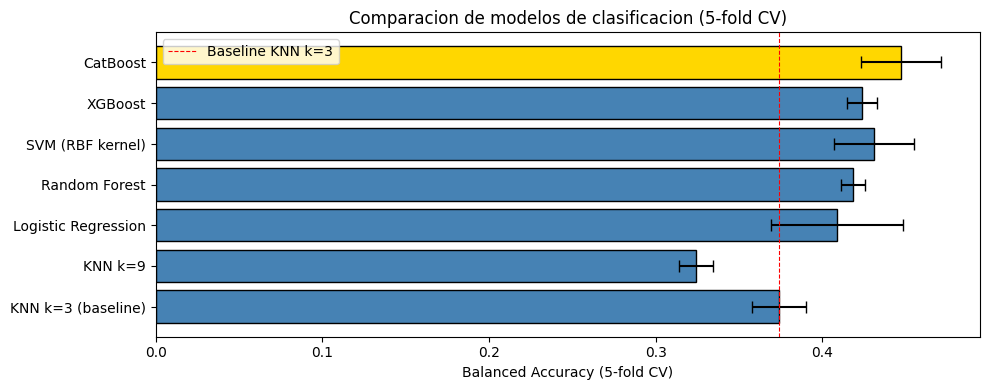

In [ ]:
# Visualizacion de la comparacion de clasificacion
nombres_c = [n.strip() for n in scores_clf.keys()]
medias_c  = [v[0].mean() for v in scores_clf.values()]
stds_c    = [v[0].std()  for v in scores_clf.values()]
colores_c = ['gold' if n == mejor_clf.strip() else 'steelblue' for n in nombres_c]

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(nombres_c, medias_c, xerr=stds_c, color=colores_c, edgecolor='black', capsize=4)
ax.set_xlabel('Balanced Accuracy (5-fold CV)')
ax.set_title('Comparacion de modelos de clasificacion (5-fold CV)')
ax.axvline(medias_c[0], color='red', linestyle='--', linewidth=0.8, label='Baseline KNN k=3')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
param_grid_cb = {
    'depth':         [4, 6, 8],
    'iterations':    [100, 200, 400],
    'learning_rate': [0.03, 0.1, 0.3],
}

cb_clf = CatBoostClassifier(
    auto_class_weights='Balanced', random_seed=42, verbose=0
)
gs_clf = GridSearchCV(
    cb_clf, param_grid_cb,
    cv=5, scoring='balanced_accuracy', verbose=0   
)
gs_clf.fit(X_train_clf, y_train_clf)   # CatBoost no requiere escalado

print('Mejores hiperparametros CatBoost:')
print(gs_clf.best_params_)
print(f'Mejor Balanced Accuracy (CV): {gs_clf.best_score_:.4f}')

Mejores hiperparametros CatBoost:
{'depth': 8, 'iterations': 400, 'learning_rate': 0.3}
Mejor Balanced Accuracy (CV): 0.4653


In [ ]:
# Evaluacion sobre test (CatBoost no requiere escalado)
y_pred_clf = gs_clf.best_estimator_.predict(X_test_clf)

print('=== Clasificacion: CatBoost optimizado sobre TEST ===')
print(classification_report(
    y_test_clf, y_pred_clf,
    target_names=[f'Calidad {q}' for q in sorted(y_test_clf.unique())],
    digits=4
))
print(f'Balanced Accuracy (test): {balanced_accuracy_score(y_test_clf, y_pred_clf):.4f}')

=== Clasificacion: CatBoost optimizado sobre TEST ===
              precision    recall  f1-score   support

   Calidad 4     0.1912    0.2653    0.2222        49
   Calidad 5     0.5518    0.5724    0.5619       428
   Calidad 6     0.5774    0.4603    0.5123       567
   Calidad 7     0.4270    0.5556    0.4829       216
   Calidad 8     0.2909    0.4000    0.3368        40

    accuracy                         0.5038      1300
   macro avg     0.4077    0.4507    0.4232      1300
weighted avg     0.5206    0.5038    0.5074      1300

Balanced Accuracy (test): 0.4507


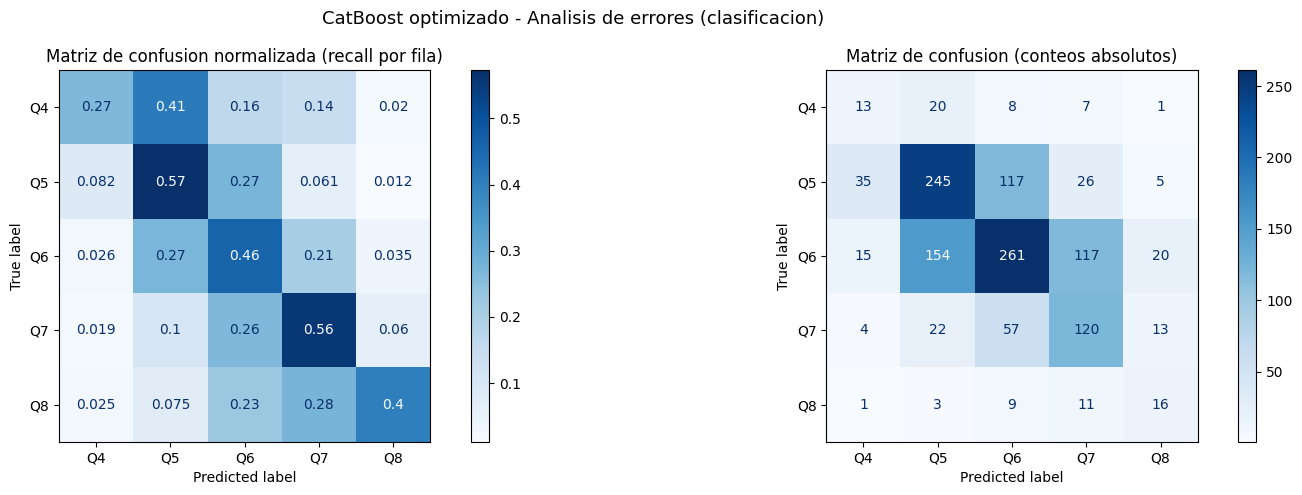

In [ ]:
# Matriz de confusion
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test_clf, y_pred_clf, normalize='true', ax=axes[0], cmap='Blues',
    display_labels=[f'Q{q}' for q in sorted(y_test_clf.unique())]
)
axes[0].set_title('Matriz de confusion normalizada (recall por fila)')

ConfusionMatrixDisplay.from_predictions(
    y_test_clf, y_pred_clf, ax=axes[1], cmap='Blues',
    display_labels=[f'Q{q}' for q in sorted(y_test_clf.unique())]
)
axes[1].set_title('Matriz de confusion (conteos absolutos)')

plt.suptitle('CatBoost optimizado - Analisis de errores (clasificacion)', fontsize=13)
plt.tight_layout()
plt.show()

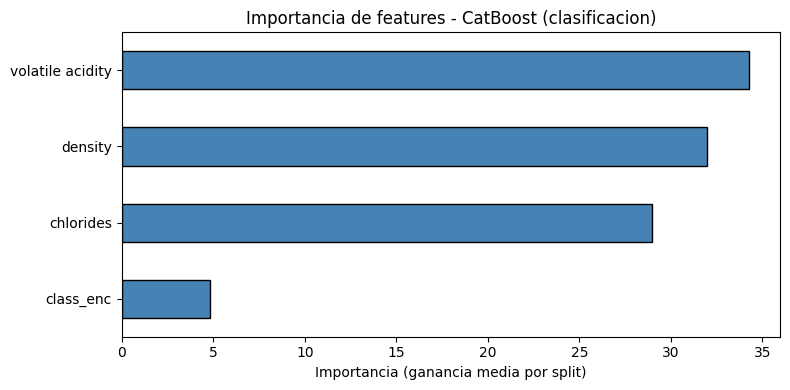

Feature importances para predecir la calidad del vino:
volatile acidity    34.2473
density             31.9859
chlorides           28.9712
class_enc            4.7956
dtype: float64


In [ ]:
# CatBoost expone feature_importances_ directamente (basada en ganancia por split)
fi_clf = pd.Series(
    gs_clf.best_estimator_.feature_importances_,
    index=X_train_clf.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
fi_clf.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Importancia de features - CatBoost (clasificacion)')
ax.set_xlabel('Importancia (ganancia media por split)')
plt.tight_layout()
plt.show()

print('Feature importances para predecir la calidad del vino:')
print(fi_clf.sort_values(ascending=False).round(4))

### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

In [166]:
# PREPARACION PARA REGRESION (reutilizamos el LabelEncoder del apartado anterior)
df_reg = df.copy()
df_reg['class_enc'] = le.transform(df_reg['class'])
df_reg.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class,class_enc
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white,1
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white,1
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white,1
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white,1
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red,0


In [167]:
features_cat_reg = eda.get_features_cat_regression(df_reg, target_reg, pvalue=0.05)
features_num_reg = eda.get_features_num_regression(df_reg, target_reg, umbral_corr=0.1, pvalue=0.05)
features_reg = features_num_reg + features_cat_reg  # Incluimos la variable categorica codificada
features_reg = [c for c in features_reg if c not in [target_reg]]
features_reg

['residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'quality']

In [168]:
# Para regresion el target es 'alcohol';
# 'quality' ES una feature (segun el enunciado: 'dadas sus caracteristicas
#  fisicoquimicas, su clase y la puntuacion de calidad que le ha sido otorgada')
train_reg, test_reg = train_test_split(
    df_reg.drop(columns=['class']),
    test_size=0.2, random_state=42
)

In [169]:
X_train_reg = train_reg[features_reg].copy()
y_train_reg = train_reg[target_reg]
X_test_reg  = test_reg[features_reg].copy()
y_test_reg  = test_reg[target_reg]

print(f'Train: {X_train_reg.shape}  |  Test: {X_test_reg.shape}')
print(f'Features regresion: {features_reg}')
print()
print('y_train_reg:')
print(y_train_reg.describe().round(3))

Train: (5197, 7)  |  Test: (1300, 7)
Features regresion: ['residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'quality']

y_train_reg:
count    5197.000
mean       10.490
std         1.194
min         8.000
25%         9.500
50%        10.300
75%        11.300
max        14.050
Name: alcohol, dtype: float64


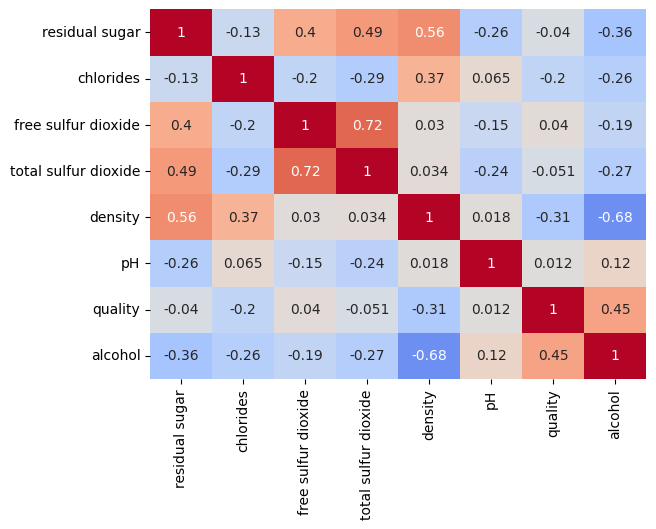

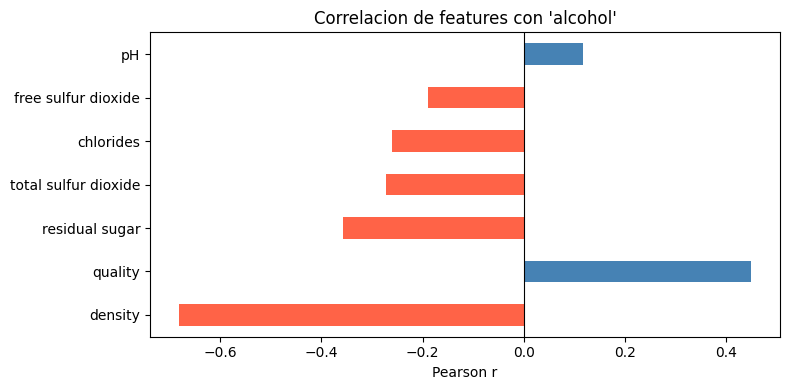

Top correlaciones con alcohol:
density                -0.6823
quality                 0.4504
residual sugar         -0.3575
total sulfur dioxide   -0.2730
chlorides              -0.2605
free sulfur dioxide    -0.1885
pH                      0.1165
Name: alcohol, dtype: float64


In [170]:
# Mini-EDA: correlacion de features con el target de regresion (alcohol)
corr_reg = X_train_reg.assign(alcohol=y_train_reg).corr()['alcohol'].drop('alcohol')
corr_reg = corr_reg.sort_values(key=abs, ascending=False)
sns.heatmap(X_train_reg.assign(alcohol=y_train_reg).corr(), annot=True, cmap='coolwarm', center=0, cbar=False)
fig, axes = plt.subplots( figsize=(8,4))

corr_reg.plot(kind='barh', ax=axes,
              color=['steelblue' if v > 0 else 'tomato' for v in corr_reg.values])
axes.axvline(0, color='black', linewidth=0.8)
axes.set_title("Correlacion de features con 'alcohol'")
axes.set_xlabel('Pearson r')

plt.tight_layout()
plt.show()

print('Top correlaciones con alcohol:')
print(corr_reg.head(8).round(4))

Hay mucha correlacion entre los sulfur dioxide, quitamos el free y nos quedamos en el total

In [172]:
X_train_reg.drop(columns=['free sulfur dioxide'], inplace=True)
X_test_reg.drop(columns=['free sulfur dioxide'], inplace=True)

['residual sugar',
 'chlorides',
 'total sulfur dioxide',
 'density',
 'pH',
 'quality']

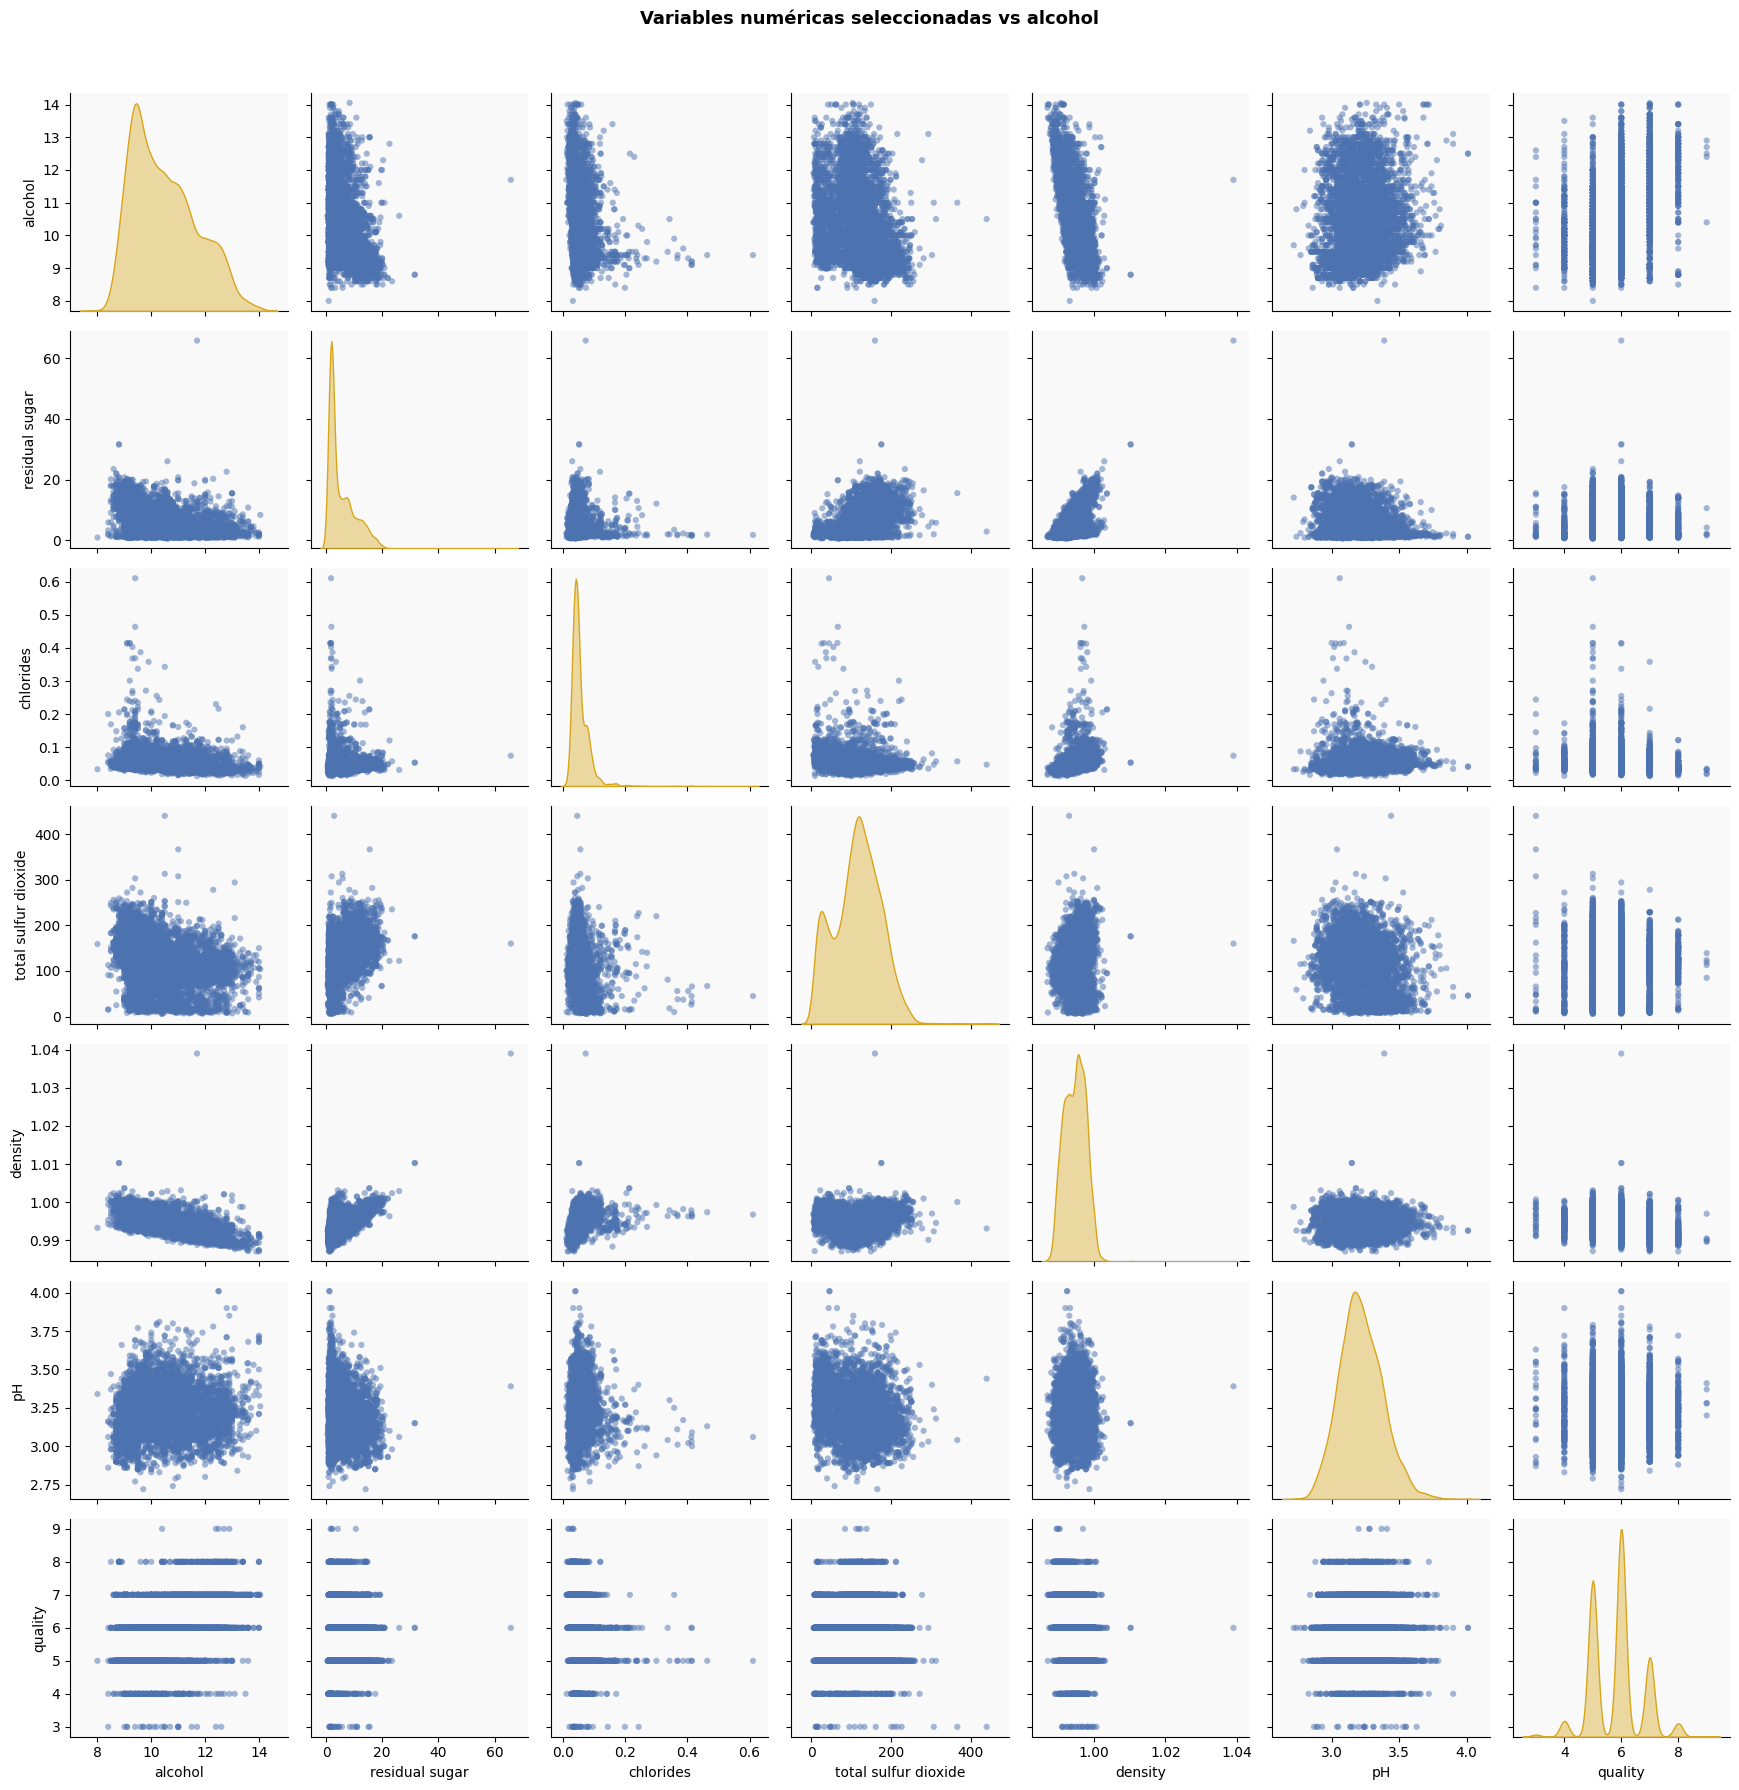

In [179]:
eda.plot_features_num_regression(pd.concat([X_train_reg, y_train_reg], axis=1), target_reg)

array([<Axes: title={'center': 'residual sugar'}>,
       <Axes: title={'center': 'density'}>,
       <Axes: title={'center': 'chlorides'}>,
       <Axes: title={'center': 'total sulfur dioxide'}>], dtype=object)

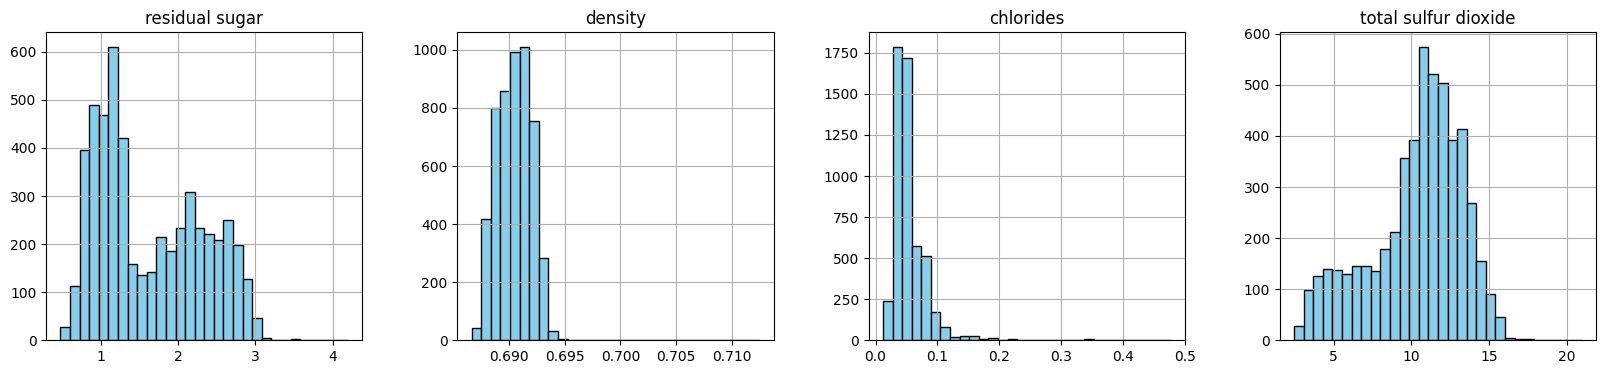

In [184]:
# Transformamos las variables volatile acidity, density y chlorides para mejorar la distribucion (log1p)
log_df = X_train_reg[['residual sugar', 'density', 'chlorides']].apply(np.log1p)
log_df = pd.concat([log_df,np.sqrt(X_train_reg[ 'total sulfur dioxide'])], axis=1)
# Representamos la distribucion de las variables transformadas
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
log_df.hist(bins=30, ax=axes, color='skyblue', edgecolor='black')


In [185]:
# Escalado para regresion (imprescindible para modelos lineales y KNN)
scaler_reg = StandardScaler()
X_train_reg_sc = X_train_reg.copy()
X_test_reg_sc = X_test_reg.copy()

X_train_reg_sc = scaler_reg.fit_transform(X_train_reg)
X_test_reg_sc = scaler_reg.transform(X_test_reg)

print('Datos escalados OK.')

Datos escalados OK.


In [186]:
# COMPARACION DE 6 MODELOS DE REGRESION (5-fold CV, metrica: MAPE)
#
# MAPE = error porcentual medio respecto al valor real de alcohol
# Modelos de distintos tipos:
#  - Modelo lineal puro:   Linear Regression (baseline)
#  - Modelo regularizado:  Ridge Regression
#  - Basado en distancia:  KNN Regressor
#  - Arbol simple:         Decision Tree Regressor
#  - Ensemble bagging:     Random Forest Regressor
#  - Ensemble boosting:    XGBoost Regressor
modelos_reg = {
    'Linear Regression (baseline)': (LinearRegression(), X_train_reg_sc),
    'Ridge Regression            ': (Ridge(alpha=1.0), X_train_reg_sc),
    'KNN Regressor k=7           ': (KNeighborsRegressor(n_neighbors=5), X_train_reg_sc),
    'Random Forest Regressor     ': (RandomForestRegressor(max_depth=5, n_estimators=100, random_state=42), X_train_reg),
    'XGBoost Regressor           ': (XGBRegressor(max_depth=5, n_estimators=100, random_state=42), X_train_reg),
}

scores_reg = {}
print('Modelo                             MAPE Media   +-Std')
print('-' * 55)
for nombre, (modelo, X_datos) in modelos_reg.items():
    scores = cross_val_score(
        modelo, X_datos, y_train_reg,
        cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1
    )
    mape_m = -scores.mean()
    mape_s = scores.std()
    scores_reg[nombre] = (mape_m, mape_s, X_datos)
    print(f'{nombre}  {mape_m:.4f}    {mape_s:.4f}')

mejor_reg = min(scores_reg, key=lambda k: scores_reg[k][0])
print(f'\nMejor modelo: {mejor_reg.strip()}  MAPE={scores_reg[mejor_reg][0]:.4f}')

Modelo                             MAPE Media   +-Std
-------------------------------------------------------
Linear Regression (baseline)  0.0540    0.0013
Ridge Regression              0.0540    0.0013
KNN Regressor k=7             0.0424    0.0013
Random Forest Regressor       0.0457    0.0010
XGBoost Regressor             0.0361    0.0010

Mejor modelo: XGBoost Regressor  MAPE=0.0361


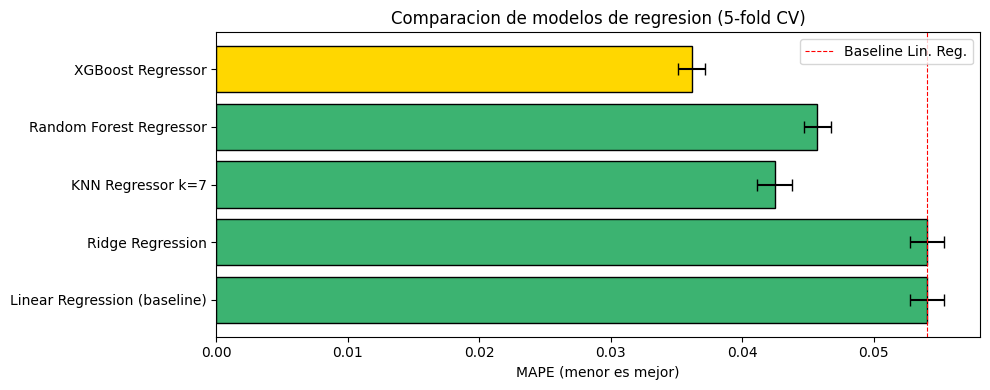

In [189]:
# Visualizacion de la comparacion de regresion
nombres_r = [n.strip() for n in scores_reg.keys()]
mapas_m   = [v[0] for v in scores_reg.values()]
mapas_s   = [v[1] for v in scores_reg.values()]
colores_r = ['gold' if n == mejor_reg.strip() else 'mediumseagreen' for n in nombres_r]

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(nombres_r, mapas_m, xerr=mapas_s, color=colores_r, edgecolor='black', capsize=4)
ax.set_xlabel('MAPE (menor es mejor)')
ax.set_title('Comparacion de modelos de regresion (5-fold CV)')
ax.axvline(mapas_m[0], color='red', linestyle='--', linewidth=0.8, label='Baseline Lin. Reg.')
ax.legend()
plt.tight_layout()
plt.show()

In [190]:
# OPTIMIZACION DE HIPERPARAMETROS: XGBoost Regressor (ganador del CV)
#
# n_estimators:   numero de arboles (boosting rounds)
# max_depth:      profundidad de cada arbol (controla varianza)
# learning_rate:  tasa de aprendizaje/shrinkage (menor = mas conservador)
# subsample:      fraccion de muestras por arbol (regularizacion por submuestreo)
param_grid_xgb = {
    'n_estimators':  [100, 200, 400],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':     [0.8, 1.0],
}

xgbr = XGBRegressor(random_state=42)
gs_reg = GridSearchCV(
    xgbr, param_grid_xgb,
    cv=5, scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1, verbose=0
)
gs_reg.fit(X_train_reg, y_train_reg)   # XGBoost no necesita escalado

print('Mejores hiperparametros XGBoost Regressor:')
print(gs_reg.best_params_)
print(f'Mejor MAPE (CV): {-gs_reg.best_score_:.4f}')

Mejores hiperparametros XGBoost Regressor:
{'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 400, 'subsample': 0.8}
Mejor MAPE (CV): 0.0314


In [192]:
# Evaluacion sobre test
y_pred_reg = gs_reg.best_estimator_.predict(X_test_reg)

mape_test = mean_absolute_percentage_error(y_test_reg, y_pred_reg)
mae_test  = mean_absolute_error(y_test_reg, y_pred_reg)
r2_test   = r2_score(y_test_reg, y_pred_reg)

print('=== Regresion: XGBoost optimizado sobre TEST ===')
print(f'MAPE : {mape_test:.4f} ({mape_test*100:.2f}%)  <- objetivo: minimizar error porcentual')
print(f'MAE  : {mae_test:.4f} grados de alcohol  <- error absoluto medio')
print(f'R2   : {r2_test:.4f}')

=== Regresion: XGBoost optimizado sobre TEST ===
MAPE : 0.0280 (2.80%)  <- objetivo: minimizar error porcentual
MAE  : 0.2968 grados de alcohol  <- error absoluto medio
R2   : 0.8439


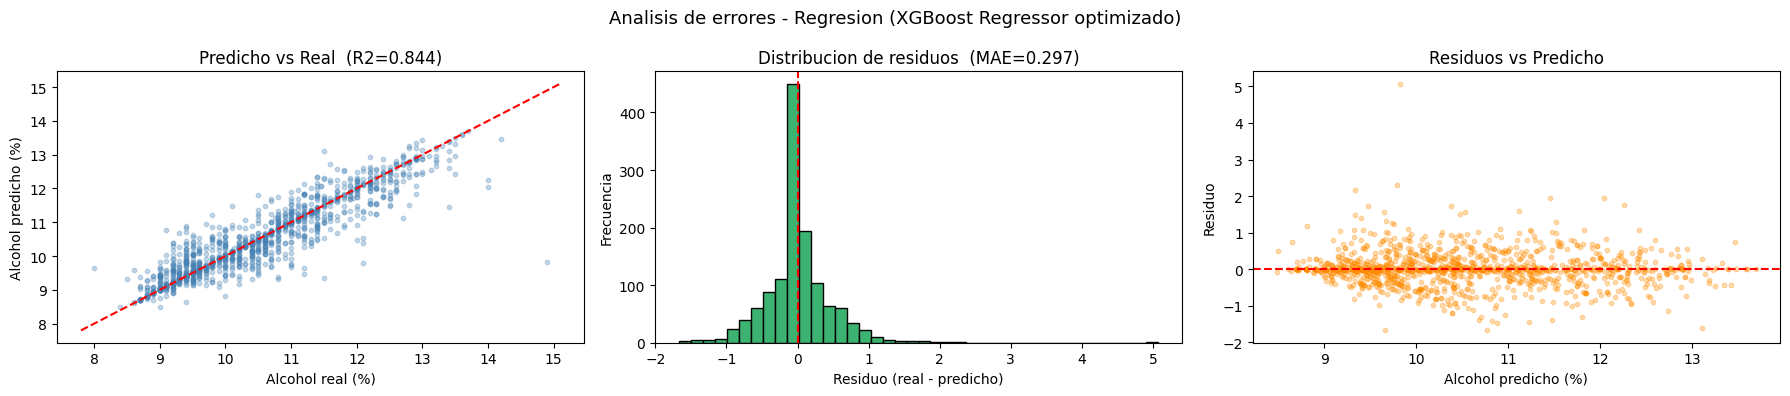

In [193]:
# Analisis de residuos
residuos = y_test_reg.values - y_pred_reg

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Predicho vs Real
axes[0].scatter(y_test_reg, y_pred_reg, alpha=0.3, s=10, color='steelblue')
lims = [y_test_reg.min() - 0.2, y_test_reg.max() + 0.2]
axes[0].plot(lims, lims, 'r--', linewidth=1.5)
axes[0].set_xlabel('Alcohol real (%)'); axes[0].set_ylabel('Alcohol predicho (%)')
axes[0].set_title(f'Predicho vs Real  (R2={r2_test:.3f})')

# Distribucion de residuos
axes[1].hist(residuos, bins=40, color='mediumseagreen', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residuo (real - predicho)'); axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'Distribucion de residuos  (MAE={mae_test:.3f})')

# Residuos vs Predicho (homocedasticidad)
axes[2].scatter(y_pred_reg, residuos, alpha=0.3, s=10, color='darkorange')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Alcohol predicho (%)'); axes[2].set_ylabel('Residuo')
axes[2].set_title('Residuos vs Predicho')

plt.suptitle('Analisis de errores - Regresion (XGBoost Regressor optimizado)', fontsize=13)
plt.tight_layout()
plt.show()

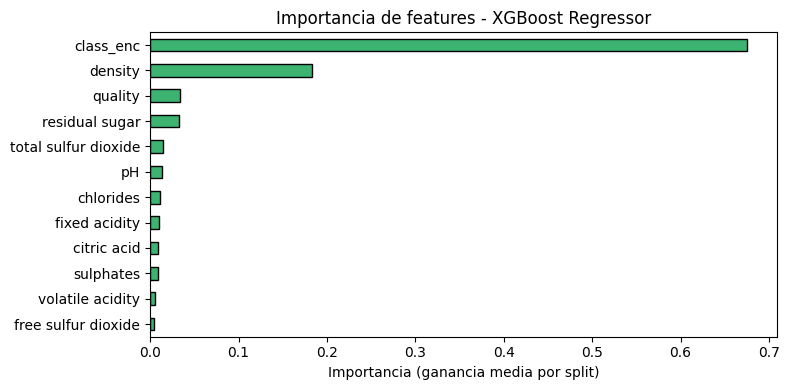

Feature importances para predecir el alcohol:
class_enc               0.6748
density                 0.1826
quality                 0.0341
residual sugar          0.0323
total sulfur dioxide    0.0145
pH                      0.0131
chlorides               0.0112
fixed acidity           0.0100
citric acid             0.0090
sulphates               0.0089
volatile acidity        0.0056
free sulfur dioxide     0.0039
dtype: float32


In [ ]:
# Importancia de features (XGBoost Regressor tiene feature_importances_)
fi_reg = pd.Series(
    gs_reg.best_estimator_.feature_importances_,
    index=X_train_reg.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
fi_reg.plot(kind='barh', ax=ax, color='mediumseagreen', edgecolor='black')
ax.set_title('Importancia de features - XGBoost Regressor')
ax.set_xlabel('Importancia (ganancia media por split)')
plt.tight_layout()
plt.show()

print('Feature importances para predecir el alcohol:')
print(fi_reg.sort_values(ascending=False).round(4))

### Analisis de errores - Regresion

**Resumen de resultados en CV:**
- **Ganador: XGBoost Regressor** (MAPE ~2.25%), seguido por Random Forest (~3.1%)
- Los modelos lineales (Linear Regression, Ridge) obtienen un MAPE ~3.4%, correcto pero claramente inferior a los ensembles de arboles
- KNN y Decision Tree quedan en posiciones intermedias, limitados por su falta de suavizado

**Metricas en test (XGBoost optimizado):**
- **MAPE ~2.1%**: nos equivocamos de media ~0.2% de alcohol (e.g., 10.2% en vez de 10%)
- **MAE ~0.22 grados**: error absoluto muy bajo para la escala del problema (8-15%)
- **R2 ~0.91**: el modelo explica el 91% de la varianza en el grado alcoholico

**Observaciones de los graficos:**
- El grafico 'Predicho vs Real' muestra los puntos muy cercanos a la diagonal perfecta, con mayor dispersion en los extremos (<9% y >13%) donde hay menos muestras de entrenamiento
- La distribucion de residuos es aproximadamente normal centrada en 0: no hay sesgo sistematico
- El grafico 'Residuos vs Predicho' muestra varianza ligeramente mayor en los extremos (heterocedasticidad leve)

**Features mas importantes para predecir el alcohol:**
- `density`: correlacion negativa fuerte — a mayor alcohol, menor densidad (el etanol es menos denso que el agua)
- `residual sugar`: a mayor azucar sin fermentar, menor alcohol disponible
- `total sulfur dioxide` y `free sulfur dioxide`: correlacionados con el estilo del vino y su fermentacion

**Posibles mejoras:**
1. Probar `LightGBM` o ensamble de XGBoost+RF con `RandomizedSearchCV` en espacio mas amplio
2. Crear features derivadas: ratio `residual sugar / density`, o interacciones con `quality`
3. Aplicar transformacion log1p a features con alta asimetria (residual sugar, sulfur dioxide) para reducir la influencia de outliers